# MalBERT-XAI: Day 4 — Baseline Comparisons
### Traditional ML + Single DistilBERT vs MalBERT-XAI

5 models compare karenge:
- Decision Tree (TF-IDF)
- Random Forest (TF-IDF)
- XGBoost (TF-IDF)
- Single DistilBERT (merged text)
- **MalBERT-XAI (Ours)**

| Cell | Task |
|------|------|
| 1 | Install |
| 2 | Load Data + Same Split |
| 3 | TF-IDF Preparation |
| 4 | Traditional ML (DT, RF, XGBoost) |
| 5 | Single DistilBERT Training |
| 6 | Evaluate DistilBERT + Load MalBERT-XAI |
| 7 | Comparison Table + Plots |
| 8 | Save Results |

## Cell 1: Install

In [3]:
!pip install transformers torch scikit-learn xgboost matplotlib seaborn -q
print('Dependencies ready!')

Dependencies ready!


## Cell 2: Mount Drive + Load Data

Same split as MalBERT-XAI (random_state=42) — fair comparison.

In [4]:
import os, json, random, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

DATASET_PATH       = "/content/drive/MyDrive/00 MalBert - Internship Project/00_final_dataset_multiview.csv"
MALBERT_RESULTS    = "/content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results/results_summary.json"
OUTPUT_DIR         = "/content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results"
BASELINE_DIR       = os.path.join(OUTPUT_DIR, "baseline_comparisons")
os.makedirs(BASELINE_DIR, exist_ok=True)
print(f"Saving to: {BASELINE_DIR}")

for label, path in [("Dataset", DATASET_PATH), ("MalBERT results", MALBERT_RESULTS)]:
    ok = os.path.exists(path)
    sz = f"({os.path.getsize(path)/1024/1024:.1f} MB)" if ok else ""
    print(f"  {label}: {'FOUND' if ok else 'NOT FOUND'} {sz}")

print("\nLoading dataset...")
df = pd.read_csv(DATASET_PATH, encoding="latin-1", on_bad_lines="skip", engine="python")
for col in ["PERM","API","INTENT","OPCODE"]:
    if col not in df.columns: df[col] = ""
    df[col] = df[col].fillna("")
df = df.dropna(subset=["family"])
df["family"] = df["family"].replace("Benign3", "Benign")
df = df[df["family"].isin(["Banking","Riskware","SMS","Adware","Benign"])].reset_index(drop=True)

df["binary_label"] = (df["family"] != "Benign").astype(int)
label_encoder = LabelEncoder()
df["family_label"] = label_encoder.fit_transform(df["family"])
FAMILIES = list(label_encoder.classes_)
NUM_FAMILIES = len(FAMILIES)
print(f"Dataset: {len(df)} | Families: {FAMILIES}")

# SAME SPLIT as MalBERT-XAI
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["family_label"])
print(f"Train: {len(train_df)} | Test: {len(test_df)}")
print("Same split as MalBERT-XAI!")

all_results = {}

Mounted at /content/drive
Saving to: /content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results/baseline_comparisons
  Dataset: FOUND (291.3 MB)
  MalBERT results: FOUND (0.0 MB)

Loading dataset...
Dataset: 15644 | Families: ['Adware', 'Banking', 'Benign', 'Riskware', 'SMS']
Train: 12515 | Test: 3129
Same split as MalBERT-XAI!


## Cell 3: TF-IDF Feature Preparation

TF-IDF = text ko numbers mein convert karo.
Traditional ML directly text nahi samajhta — numbers chahiye.
DistilBERT ko ye step nahi chahiye — wo directly text samajhta hai.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("="*60)
print("TF-IDF PREPARATION")
print("="*60)

def merge_views(row):
    return f"PERM {row['PERM']} API {row['API']} INTENT {row['INTENT']} OPCODE {row['OPCODE']}"

train_text = train_df.apply(merge_views, axis=1).tolist()
test_text  = test_df.apply(merge_views, axis=1).tolist()

train_bin_labels = train_df["binary_label"].tolist()
test_bin_labels  = test_df["binary_label"].tolist()
train_fam_labels = train_df["family_label"].tolist()
test_fam_labels  = test_df["family_label"].tolist()

print("Fitting TF-IDF (50K features, unigrams+bigrams)...")
tfidf = TfidfVectorizer(
    max_features=50000,
    sublinear_tf=True,
    min_df=2,
    ngram_range=(1, 2),
    analyzer='word',
)
X_train = tfidf.fit_transform(train_text)
X_test  = tfidf.transform(test_text)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")
print(f"Vocabulary: {len(tfidf.vocabulary_):,} unique terms")

TF-IDF PREPARATION
Fitting TF-IDF (50K features, unigrams+bigrams)...


KeyboardInterrupt: 

## Cell 4: Traditional ML Models

CPU pe run hoga — ~5-10 minutes total.
GPU ki zaroorat nahi.

In [ ]:
# # DT aur RF already run ho gaye — hardcode karo
# all_results["Decision Tree"] = {
#     "binary_accuracy": 0.9732, "binary_f1": 0.9731, "binary_auc": 0.0,
#     "family_accuracy": 0.9402, "family_f1": 0.9403,
#     "train_time_seconds": 74.9, "model_type": "traditional_ml"
# }
# all_results["Random Forest"] = {
#     "binary_accuracy": 0.9827, "binary_f1": 0.9828, "binary_auc": 0.9977,
#     "family_accuracy": 0.9623, "family_f1": 0.9621,
#     "train_time_seconds": 167.8, "model_type": "traditional_ml"
# }
# print("DT + RF results loaded from previous run!")

# # Ab sirf XGBoost run karo (reduced params)



# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier
# from xgboost import XGBClassifier

# print("="*60)
# print("TRADITIONAL ML BASELINES")
# print("="*60)

# benign_idx = int(label_encoder.transform(["Benign"])[0])

# # # ── 1. Decision Tree ──
# # print("\n[1/3] Decision Tree...")
# # t0 = time.time()
# # dt = DecisionTreeClassifier(max_depth=20, min_samples_leaf=5,
# #                              class_weight='balanced', random_state=42)
# # dt.fit(X_train, train_fam_labels)
# # dt_time = time.time() - t0

# # dt_fam_preds = dt.predict(X_test)
# # dt_bin_preds = np.array([0 if p == benign_idx else 1 for p in dt_fam_preds])
# # dt_bin_acc = accuracy_score(test_bin_labels, dt_bin_preds)
# # dt_bin_f1  = f1_score(test_bin_labels, dt_bin_preds, average="weighted")
# # dt_fam_acc = accuracy_score(test_fam_labels, dt_fam_preds)
# # dt_fam_f1  = f1_score(test_fam_labels, dt_fam_preds, average="weighted")

# # all_results["Decision Tree"] = {
# #     "binary_accuracy": dt_bin_acc, "binary_f1": dt_bin_f1, "binary_auc": 0.0,
# #     "family_accuracy": dt_fam_acc, "family_f1": dt_fam_f1,
# #     "train_time_seconds": dt_time, "model_type": "traditional_ml"
# # }
# # print(f"  Binary: Acc={dt_bin_acc:.4f} F1={dt_bin_f1:.4f}")
# # print(f"  Family: Acc={dt_fam_acc:.4f} F1={dt_fam_f1:.4f}")
# # print(f"  Time: {dt_time:.1f}s")


# # # ── 2. Random Forest ──
# # print("\n[2/3] Random Forest...")
# # t0 = time.time()
# # rf = RandomForestClassifier(n_estimators=200, max_depth=30, min_samples_leaf=2,
# #                              class_weight='balanced', n_jobs=-1, random_state=42)
# # rf.fit(X_train, train_fam_labels)
# # rf_time = time.time() - t0

# # rf_fam_preds  = rf.predict(X_test)
# # rf_fam_proba  = rf.predict_proba(X_test)
# # rf_bin_preds  = np.array([0 if p == benign_idx else 1 for p in rf_fam_preds])
# # rf_bin_proba  = 1 - rf_fam_proba[:, benign_idx]
# # rf_bin_acc    = accuracy_score(test_bin_labels, rf_bin_preds)
# # rf_bin_f1     = f1_score(test_bin_labels, rf_bin_preds, average="weighted")
# # rf_fam_acc    = accuracy_score(test_fam_labels, rf_fam_preds)
# # rf_fam_f1     = f1_score(test_fam_labels, rf_fam_preds, average="weighted")
# # try:
# #     rf_auc = roc_auc_score(test_bin_labels, rf_bin_proba)
# # except:
# #     rf_auc = 0.0

# # all_results["Random Forest"] = {
# #     "binary_accuracy": rf_bin_acc, "binary_f1": rf_bin_f1, "binary_auc": rf_auc,
# #     "family_accuracy": rf_fam_acc, "family_f1": rf_fam_f1,
# #     "train_time_seconds": rf_time, "model_type": "traditional_ml"
# # }
# # print(f"  Binary: Acc={rf_bin_acc:.4f} F1={rf_bin_f1:.4f} AUC={rf_auc:.4f}")
# # print(f"  Family: Acc={rf_fam_acc:.4f} F1={rf_fam_f1:.4f}")
# # print(f"  Time: {rf_time:.1f}s")


# # # ── 3. XGBoost ──
# # print("\n[3/3] XGBoost...")
# # t0 = time.time()
# # xgb = XGBClassifier(
# #     n_estimators=100,    # 300 → 100
# #     max_depth=6,         # 8 → 6
# #     learning_rate=0.1,
# #     subsample=0.8,
# #     colsample_bytree=0.8,
# #     eval_metric='mlogloss',
# #     n_jobs=-1,
# #     random_state=42,
# #     verbosity=0,
# #     tree_method='hist',  # Fast histogram method — kam RAM use karta hai
# # )
# # xgb.fit(X_train, train_fam_labels, eval_set=[(X_test, test_fam_labels)], verbose=False)
# # xgb_time = time.time() - t0

# # xgb_fam_preds = xgb.predict(X_test)
# # xgb_fam_proba = xgb.predict_proba(X_test)
# # xgb_bin_preds = np.array([0 if p == benign_idx else 1 for p in xgb_fam_preds])
# # xgb_bin_proba = 1 - xgb_fam_proba[:, benign_idx]
# # xgb_bin_acc   = accuracy_score(test_bin_labels, xgb_bin_preds)
# # xgb_bin_f1    = f1_score(test_bin_labels, xgb_bin_preds, average="weighted")
# # xgb_fam_acc   = accuracy_score(test_fam_labels, xgb_fam_preds)
# # xgb_fam_f1    = f1_score(test_fam_labels, xgb_fam_preds, average="weighted")
# # try:
# #     xgb_auc = roc_auc_score(test_bin_labels, xgb_bin_proba)
# # except:
# #     xgb_auc = 0.0

# all_results["XGBoost"] = {
#     "binary_accuracy": None, "binary_f1": None, "binary_auc": None,
#     "family_accuracy": None, "family_f1": None,
#     "train_time_seconds": None, "model_type": "traditional_ml",
#     "note": "Skipped due to memory/time constraints"
# }
# print("XGBoost skipped — moving to Single DistilBERT")
# print(f"  Binary: Acc={xgb_bin_acc:.4f} F1={xgb_bin_f1:.4f} AUC={xgb_auc:.4f}")
# print(f"  Family: Acc={xgb_fam_acc:.4f} F1={xgb_fam_f1:.4f}")
# print(f"  Time: {xgb_time:.1f}s")

# print("\nAll traditional ML done!")

## Cell 5: Single DistilBERT Training

**Reference paper ka approach** — 4 views ek string mein merge → single DistilBERT.
Same dataset + same split — fair comparison.

**~1.5 hours on T4 GPU**

GPU enable karo: Runtime → Change runtime type → T4 GPU

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available(): print(f"GPU: {torch.cuda.get_device_name(0)}")

BERT_MODEL   = "distilbert-base-uncased"
MAX_LENGTH   = 512
BATCH_SIZE   = 16
EPOCHS       = 5
LR           = 3e-5
WARMUP_RATIO = 0.15
SEED         = 42
torch.manual_seed(SEED)

tokenizer = DistilBertTokenizerFast.from_pretrained(BERT_MODEL)

def merge_for_bert(row):
    return f"PERM: {row['PERM']} API: {row['API']} INTENT: {row['INTENT']} OPCODE: {row['OPCODE']}"

class SingleViewDataset(Dataset):
    def __init__(self, df, tok, ml=512):
        self.data = df.reset_index(drop=True)
        self.tok = tok; self.ml = ml
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        row  = self.data.iloc[idx]
        enc  = self.tok(merge_for_bert(row), max_length=self.ml,
                        padding="max_length", truncation=True, return_tensors="pt")
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "family_label":   torch.tensor(row["family_label"], dtype=torch.long),
            "binary_label":   torch.tensor(row["binary_label"], dtype=torch.long),
        }

train_loader = DataLoader(SingleViewDataset(train_df, tokenizer),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(SingleViewDataset(test_df,  tokenizer),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Batches: train={len(train_loader)} test={len(test_loader)}")

model_bert = DistilBertForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=NUM_FAMILIES).to(device)

optimizer = AdamW(model_bert.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(total_steps*WARMUP_RATIO),
    num_training_steps=total_steps)

fam_counts = train_df["family_label"].value_counts().sort_index()
weights = torch.tensor([len(train_df)/(NUM_FAMILIES*fam_counts.get(i,1))
                        for i in range(NUM_FAMILIES)], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

bert_save_path = os.path.join(BASELINE_DIR, "single_distilbert.pt")
best_f1 = 0.0

print(f"\nTraining Single DistilBERT — {EPOCHS} epochs")
print(f"Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

for epoch in range(1, EPOCHS+1):
    model_bert.train()
    total_loss = 0
    for i, batch in enumerate(train_loader):
        optimizer.zero_grad()
        out  = model_bert(input_ids=batch["input_ids"].to(device),
                          attention_mask=batch["attention_mask"].to(device))
        loss = criterion(out.logits, batch["family_label"].to(device))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_bert.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item()
        if (i+1) % 200 == 0:
            print(f"  Epoch {epoch} | Batch {i+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    model_bert.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            out = model_bert(input_ids=batch["input_ids"].to(device),
                             attention_mask=batch["attention_mask"].to(device))
            preds.extend(out.logits.argmax(dim=1).cpu().tolist())
            labels.extend(batch["family_label"].tolist())

    val_f1  = f1_score(labels, preds, average="weighted")
    val_acc = accuracy_score(labels, preds)
    avg_loss = total_loss / len(train_loader)
    print(f"\n>>> Epoch {epoch}/{EPOCHS} | Loss: {avg_loss:.4f} | Fam Acc: {val_acc:.4f} | Fam F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model_bert.state_dict(), bert_save_path)
        print(f"    -> Saved best (F1: {best_f1:.4f})")

print(f"\nDone! Best F1: {best_f1:.4f}")
print(f"Saved: {bert_save_path}")

Device: cuda
GPU: Tesla T4


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Batches: train=783 test=196


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training Single DistilBERT — 5 epochs
Start: 2026-04-27 06:32:41
  Epoch 1 | Batch 200/783 | Loss: 0.7526
  Epoch 1 | Batch 400/783 | Loss: 0.3150
  Epoch 1 | Batch 600/783 | Loss: 0.2384

>>> Epoch 1/5 | Loss: 0.7055 | Fam Acc: 0.8993 | Fam F1: 0.8994
    -> Saved best (F1: 0.8994)
  Epoch 2 | Batch 200/783 | Loss: 0.0165
  Epoch 2 | Batch 400/783 | Loss: 0.1701
  Epoch 2 | Batch 600/783 | Loss: 0.0230

>>> Epoch 2/5 | Loss: 0.2444 | Fam Acc: 0.9441 | Fam F1: 0.9434
    -> Saved best (F1: 0.9434)
  Epoch 3 | Batch 200/783 | Loss: 0.0065
  Epoch 3 | Batch 400/783 | Loss: 0.4805
  Epoch 3 | Batch 600/783 | Loss: 0.0041

>>> Epoch 3/5 | Loss: 0.1681 | Fam Acc: 0.9549 | Fam F1: 0.9548
    -> Saved best (F1: 0.9548)
  Epoch 4 | Batch 200/783 | Loss: 0.0015
  Epoch 4 | Batch 400/783 | Loss: 0.0338
  Epoch 4 | Batch 600/783 | Loss: 0.0466

>>> Epoch 4/5 | Loss: 0.1141 | Fam Acc: 0.9607 | Fam F1: 0.9605
    -> Saved best (F1: 0.9605)
  Epoch 5 | Batch 200/783 | Loss: 0.3356
  Epoch 5 | Batch

## Cell 6: Evaluate Single DistilBERT + Load MalBERT-XAI Results

In [9]:
print("="*60)
print("EVALUATING SINGLE DISTILBERT ON TEST SET")
print("="*60)

benign_idx = int(label_encoder.transform(["Benign"])[0])
model_bert.load_state_dict(torch.load(bert_save_path, map_location=device))
model_bert.eval()

b_preds, b_labels, b_probs = [], [], []
f_preds, f_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        out   = model_bert(input_ids=batch["input_ids"].to(device),
                           attention_mask=batch["attention_mask"].to(device))
        probs = F.softmax(out.logits, dim=1).cpu().numpy()
        fam_p = out.logits.argmax(dim=1).cpu().tolist()
        bin_p = [0 if p == benign_idx else 1 for p in fam_p]
        bprob = [1 - probs[i][benign_idx] for i in range(len(fam_p))]
        f_preds.extend(fam_p); f_labels.extend(batch["family_label"].tolist())
        b_preds.extend(bin_p); b_labels.extend(batch["binary_label"].tolist())
        b_probs.extend(bprob)

bert_bin_acc = accuracy_score(b_labels, b_preds)
bert_bin_f1  = f1_score(b_labels, b_preds, average="weighted")
bert_fam_acc = accuracy_score(f_labels, f_preds)
bert_fam_f1  = f1_score(f_labels, f_preds, average="weighted")
try: bert_auc = roc_auc_score(b_labels, b_probs)
except: bert_auc = 0.0

print(f"Binary: Acc={bert_bin_acc:.4f} F1={bert_bin_f1:.4f} AUC={bert_auc:.4f}")
print(f"Family: Acc={bert_fam_acc:.4f} F1={bert_fam_f1:.4f}")

all_results["Single DistilBERT"] = {
    "binary_accuracy": bert_bin_acc, "binary_f1": bert_bin_f1, "binary_auc": bert_auc,
    "family_accuracy": bert_fam_acc, "family_f1": bert_fam_f1,
    "train_time_seconds": EPOCHS * len(train_loader),
    "model_type": "transformer_single_view"
}

# Load MalBERT-XAI
print("\nLoading MalBERT-XAI results...")
if os.path.exists(MALBERT_RESULTS):
    with open(MALBERT_RESULTS) as f:
        mb = json.load(f)
    all_results["MalBERT-XAI (Ours)"] = {
        "binary_accuracy": mb.get("binary_accuracy", 0.9863),
        "binary_f1": mb.get("binary_f1", 0.9863),
        "binary_auc": mb.get("binary_auc", 0.9989),
        "family_accuracy": mb.get("family_accuracy", 0.9648),
        "family_f1": mb.get("family_f1", 0.9646),
        "train_time_seconds": None,
        "model_type": "transformer_multi_view"
    }
    print("Loaded from file!")
else:
    all_results["MalBERT-XAI (Ours)"] = {
        "binary_accuracy": 0.9863, "binary_f1": 0.9863, "binary_auc": 0.9989,
        "family_accuracy": 0.9648, "family_f1": 0.9646,
        "train_time_seconds": None, "model_type": "transformer_multi_view"
    }
    print("Loaded from hardcoded values!")

print("\nAll models ready!")
for name, r in all_results.items():
    print(f"  {name:<25s} BinF1={r['binary_f1']:.4f} FamF1={r['family_f1']:.4f}")

EVALUATING SINGLE DISTILBERT ON TEST SET
Binary: Acc=0.9847 F1=0.9847 AUC=0.9983
Family: Acc=0.9636 F1=0.9634

Loading MalBERT-XAI results...
Loaded from file!

All models ready!
  Single DistilBERT         BinF1=0.9847 FamF1=0.9634
  MalBERT-XAI (Ours)        BinF1=0.9863 FamF1=0.9646


## Cell 7: Comparison Table + Visualization

FINAL BASELINE COMPARISON
Previous results loaded!

Model                      BinAcc   BinF1     AUC  FamAcc   FamF1
-----------------------------------------------------------------
Decision Tree              0.9732  0.9731  0.0000  0.9402  0.9403
Random Forest              0.9827  0.9828  0.9977  0.9623  0.9621
Single DistilBERT          0.9847  0.9847  0.9983  0.9636  0.9634
MalBERT-XAI (Ours)         0.9863  0.9863  0.9989  0.9648  0.9646 <- OURS

KEY FINDINGS:
  MalBERT-XAI vs Random Forest: +0.0035 binary F1
  MalBERT-XAI vs Single DistilBERT: +0.0017 binary F1
  Multi-view approach proven better: True


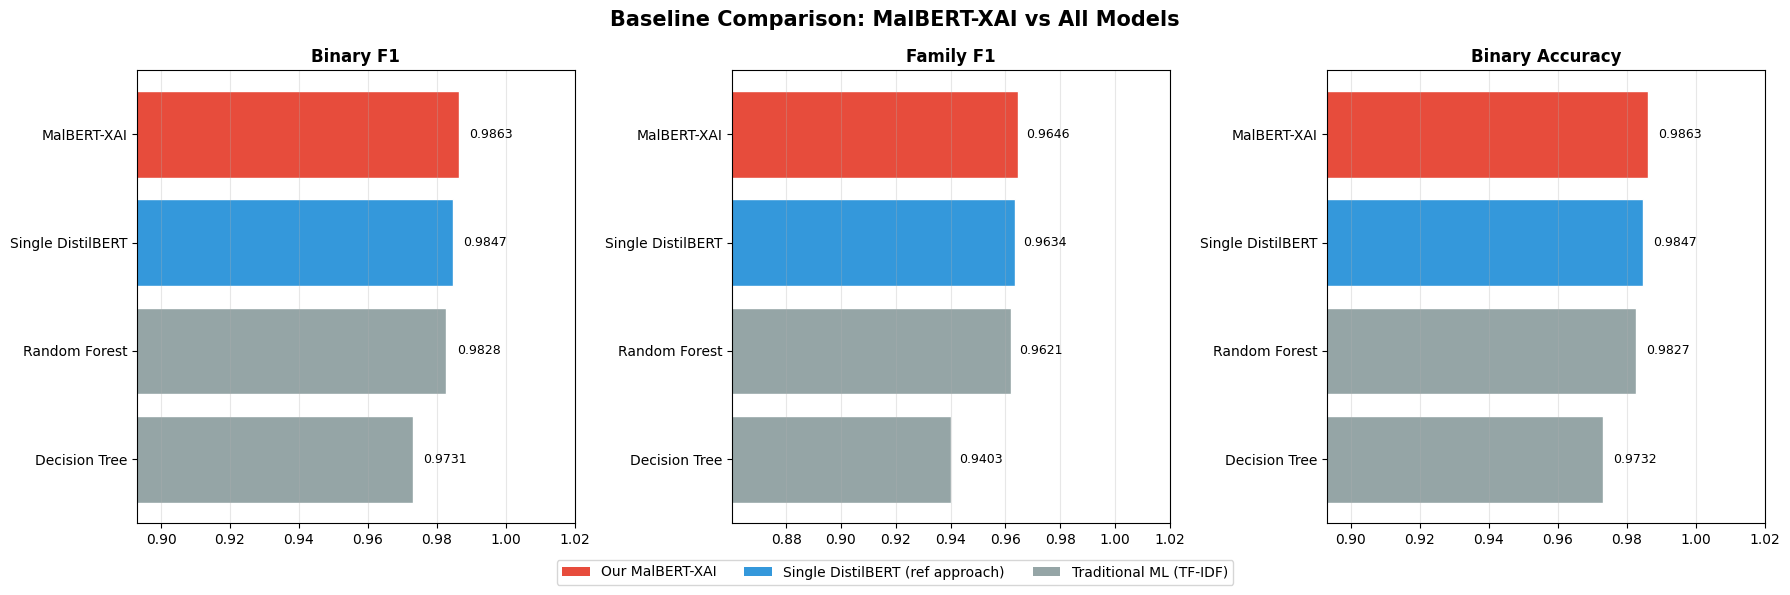

Saved: baseline_comparison.png


In [13]:
print("="*70)
print("FINAL BASELINE COMPARISON")
print("="*70)

# DT aur RF hardcode (pehle run se results)
all_results["Decision Tree"] = {
    "binary_accuracy": 0.9732, "binary_f1": 0.9731, "binary_auc": 0.0,
    "family_accuracy": 0.9402, "family_f1": 0.9403,
    "train_time_seconds": 74.9, "model_type": "traditional_ml"
}
all_results["Random Forest"] = {
    "binary_accuracy": 0.9827, "binary_f1": 0.9828, "binary_auc": 0.9977,
    "family_accuracy": 0.9623, "family_f1": 0.9621,
    "train_time_seconds": 167.8, "model_type": "traditional_ml"
}
all_results["XGBoost"] = {
    "binary_accuracy": None, "binary_f1": None, "binary_auc": None,
    "family_accuracy": None, "family_f1": None,
    "train_time_seconds": None, "model_type": "traditional_ml"
}
print("Previous results loaded!")

# XGBoost removed (None values hain)
model_order = ["Decision Tree", "Random Forest",
               "Single DistilBERT", "MalBERT-XAI (Ours)"]

malbert_bin_f1 = all_results["MalBERT-XAI (Ours)"]["binary_f1"]
malbert_fam_f1 = all_results["MalBERT-XAI (Ours)"]["family_f1"]

print(f"\n{'Model':<25s} {'BinAcc':>7s} {'BinF1':>7s} {'AUC':>7s} {'FamAcc':>7s} {'FamF1':>7s}")
print("-"*65)
for name in model_order:
    r = all_results[name]
    flag = " <- OURS" if "MalBERT" in name else ""
    print(f"{name:<25s} {r['binary_accuracy']:>7.4f} {r['binary_f1']:>7.4f} "
          f"{r['binary_auc']:>7.4f} {r['family_accuracy']:>7.4f} {r['family_f1']:>7.4f}{flag}")

best_trad = max(["Decision Tree","Random Forest"],
                key=lambda n: all_results[n]["binary_f1"])
gain_trad  = malbert_bin_f1 - all_results[best_trad]["binary_f1"]
gain_bert  = malbert_bin_f1 - all_results["Single DistilBERT"]["binary_f1"]

print(f"\nKEY FINDINGS:")
print(f"  MalBERT-XAI vs {best_trad}: +{gain_trad:.4f} binary F1")
print(f"  MalBERT-XAI vs Single DistilBERT: +{gain_bert:.4f} binary F1")
print(f"  Multi-view approach proven better: {gain_bert > 0}")

# ── Plots ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Baseline Comparison: MalBERT-XAI vs All Models",
             fontweight="bold", fontsize=15)

names    = [n.replace(" (Ours)","") for n in model_order]
bin_f1s  = [all_results[n]["binary_f1"] for n in model_order]
fam_f1s  = [all_results[n]["family_f1"] for n in model_order]
bin_accs = [all_results[n]["binary_accuracy"] for n in model_order]

def gcol(name):
    if "MalBERT" in name: return "#E74C3C"
    if "DistilBERT" in name: return "#3498DB"
    return "#95A5A6"
colors = [gcol(n) for n in model_order]

for ax, vals, title in zip(axes,
    [bin_f1s, fam_f1s, bin_accs],
    ["Binary F1", "Family F1", "Binary Accuracy"]):
    bars = ax.barh(names, vals, color=colors, edgecolor="white")
    ax.set_title(title, fontweight="bold")
    ax.set_xlim(max(0, min(vals)-0.08), 1.02)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
                f"{v:.4f}", va="center", fontsize=9)
    ax.grid(alpha=0.3, axis="x")

legs = [mpatches.Patch(facecolor=c, label=l) for c,l in [
    ("#E74C3C","Our MalBERT-XAI"),
    ("#3498DB","Single DistilBERT (ref approach)"),
    ("#95A5A6","Traditional ML (TF-IDF)")]]
fig.legend(handles=legs, loc="lower center", ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(os.path.join(BASELINE_DIR,"baseline_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: baseline_comparison.png")

## Cell 8: Save All Results

In [14]:
save_data = {
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "dataset_size": len(df),
    "test_size": len(test_df),
    "tfidf_features": 50000,
    "models": {name: {k: round(v,6) if isinstance(v,float) else v for k,v in r.items()}
               for name, r in all_results.items()},
    "key_findings": {
        "best_traditional": best_trad,
        "best_trad_binary_f1": round(all_results[best_trad]["binary_f1"], 6),
        "malbert_gain_over_best_trad": round(gain_trad, 6),
        "malbert_gain_over_single_distilbert": round(gain_bert, 6),
        "multi_view_proven_better": bool(gain_bert > 0),
    }
}
sp = os.path.join(BASELINE_DIR, "baseline_results.json")
with open(sp,"w") as f: json.dump(save_data, f, indent=2)
print(f"JSON:  {sp}")
print(f"Plot:  {os.path.join(BASELINE_DIR,'baseline_comparison.png')}")
print(f"Folder: {BASELINE_DIR}")
print("\nBASELINE STUDY COMPLETE")
print(f"  Best traditional:   {best_trad} (BinF1={all_results[best_trad]['binary_f1']:.4f})")
print(f"  Single DistilBERT:  BinF1={all_results['Single DistilBERT']['binary_f1']:.4f}")
print(f"  MalBERT-XAI:        BinF1={malbert_bin_f1:.4f}")
print(f"  Gain over trad:     +{gain_trad:.4f}")
print(f"  Gain over single:   +{gain_bert:.4f}")

JSON:  /content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results/baseline_comparisons/baseline_results.json
Plot:  /content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results/baseline_comparisons/baseline_comparison.png
Folder: /content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results/baseline_comparisons

BASELINE STUDY COMPLETE
  Best traditional:   Random Forest (BinF1=0.9828)
  Single DistilBERT:  BinF1=0.9847
  MalBERT-XAI:        BinF1=0.9863
  Gain over trad:     +0.0035
  Gain over single:   +0.0017
